In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Replace with your dataset path
df = pd.read_csv('/content/housing_price_dataset.csv')

# Preview data
print(df.head())
print(df.info())

   SquareFeet  Bedrooms  Bathrooms Neighborhood  YearBuilt        Price
0        2126         4          1        Rural       1969  215355.2836
1        2459         3          2        Rural       1980  195014.2216
2        1860         2          1       Suburb       1970  306891.0121
3        2294         2          1        Urban       1996  206786.7872
4        2130         5          2       Suburb       2001  272436.2391
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB
None


In [ ]:
X = df[['SquareFeet', 'Bedrooms', 'Neighborhood']]
y = df['Price']

In [ ]:
num_features = ['SquareFeet', 'Bedrooms']
cat_features = ['Neighborhood']

In [ ]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Create a pipeline with the preprocessor and a Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Absolute Error: 39475.98
Mean Squared Error: 2439545104.95
Root Mean Squared Error: 49391.75


In [ ]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SquareFeet', 'Bedrooms']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Neighborhood'])])),
                ('model', LinearRegression())])

In [ ]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SquareFeet', 'Bedrooms']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Neighborhood'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_gb = gb_pipeline.predict(X_test)

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{model_name} Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-" * 30)

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")

Linear Regression Performance:
MAE: 39475.98
RMSE: 49391.75
------------------------------
Gradient Boosting Performance:
MAE: 39488.40
RMSE: 49437.60
------------------------------


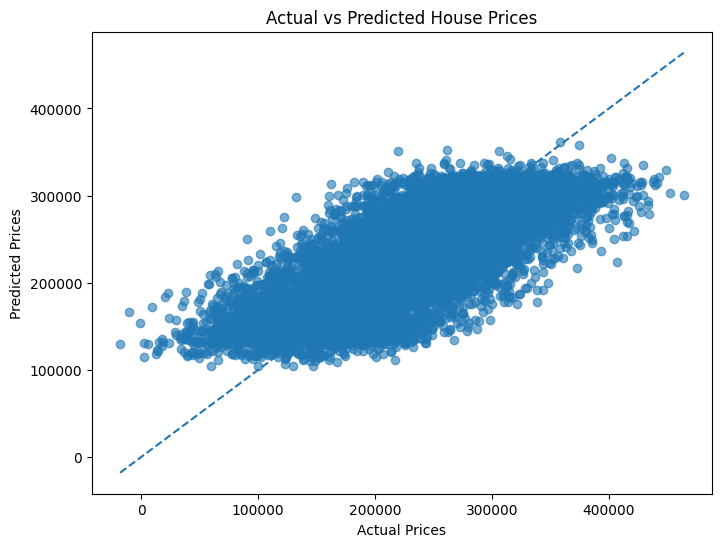

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_gb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(gb_pipeline, params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__learning_rate': 0.05, 'model__n_estimators': 100}
